# Лабораторная работа №3

## Вариант 3
Построить прогноз на 8 месяцев методом сезонной декомпозиции.

Коэффициент загрузки гостиниц в процентах (Hotel Occupancy (in %))
Данные для Chicago Central Business District Hotel Statistics. 
Предоставлены средние значения процента занятых номеров за один день. 
Усреднение по отелям и по дням месяца.
Данные расположены в столбце x3 файла.

In [1]:
# импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.api import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

In [2]:
df = pd.read_csv('./data/data.csv', sep = ';')
df

,date1,date2,x1,x2,x3,x4
0,January,1994,44.3,104.04,51.9,72.15
1,February,1994,54.7,102.74,60.1,73.47
2,March,1994,61.9,105.23,65.0,74.91
3,April,1994,69.1,113.63,69.8,79.06
4,May,1994,70.8,120.77,72.4,82.07
...,...,...,...,...,...,...
115,August,2003,NaN,NaN,NaN,NaN
116,September,2003,NaN,NaN,NaN,NaN
117,October,2003,NaN,NaN,NaN,NaN
118,November,2003,NaN,NaN,NaN,NaN


In [3]:
# удалим пустые строки
df.dropna(inplace = True)
df

,date1,date2,x1,x2,x3,x4
0,January,1994,44.3,104.04,51.9,72.15
1,February,1994,54.7,102.74,60.1,73.47
2,March,1994,61.9,105.23,65.0,74.91
3,April,1994,69.1,113.63,69.8,79.06
4,May,1994,70.8,120.77,72.4,82.07
...,...,...,...,...,...,...
107,December,2002,54.8,148.95,46.6,99.10
108,January,2003,51.6,132.89,45.3,92.88
109,February,2003,52.7,127.44,50.8,90.99
110,March,2003,65.0,147.32,55.9,99.62


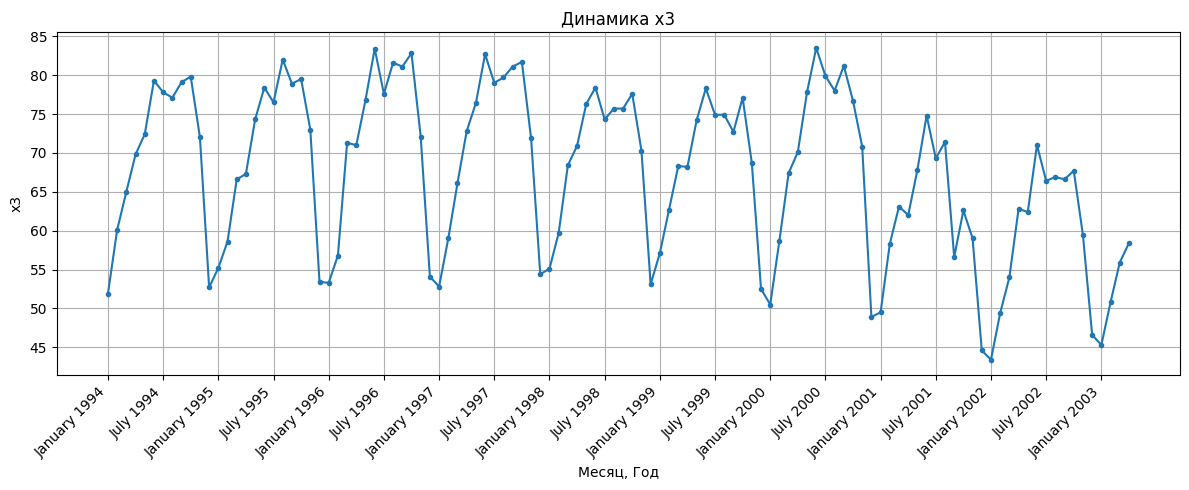

In [4]:
fig, ax = plt.subplots(figsize = (12, 5))

df['x3'].plot(ax = ax, grid = True, linewidth = 1.5, marker = 'o', markersize = 3)

labels = df['date1'].astype(str) + ' ' + df['date2'].astype(str)

step = 6
ax.set_xticks(range(0, len(df), step))
ax.set_xticklabels(labels[::step], rotation=45, ha='right')

plt.title('Динамика x3')
plt.xlabel('Месяц, Год')
plt.ylabel('x3')
plt.tight_layout()
plt.show()

In [5]:
df['date'] = pd.to_datetime(df['date2'].astype(str) + '-' + df['date1'], format = '%Y-%B')
df = df.set_index('date').sort_index()
df = df.dropna(subset = ['x3'])

In [6]:
# декомпозиция (период = 12 месяцев)
result = seasonal_decompose(df['x3'], model = 'additive', period = 12)

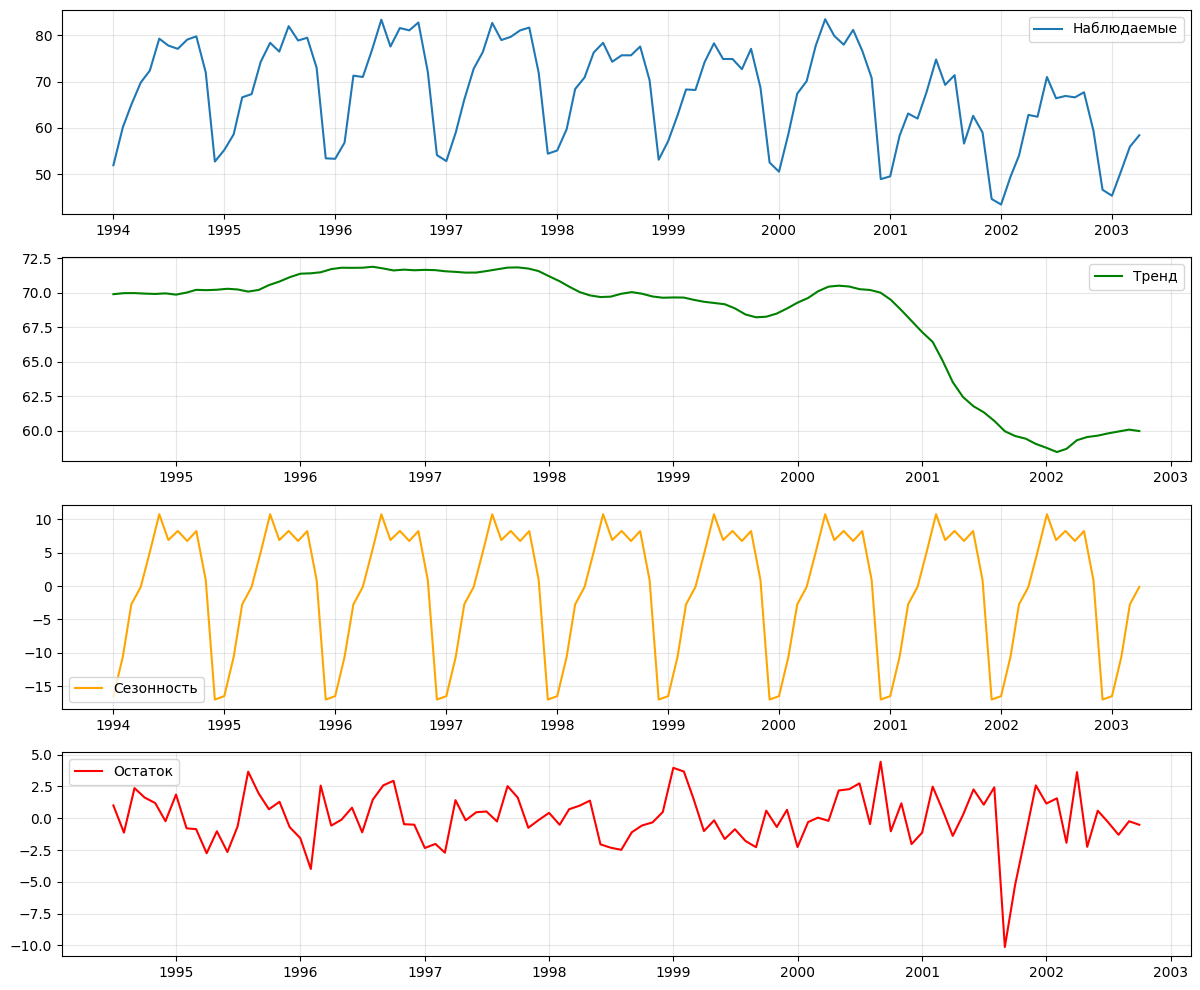

In [7]:
fig, axes = plt.subplots(4, 1, figsize = (12, 10))
axes[0].plot(result.observed, label = 'Наблюдаемые')
axes[0].legend()
axes[0].grid(True, alpha = 0.3)

axes[1].plot(result.trend, label = 'Тренд', color = 'green')
axes[1].legend()
axes[1].grid(True, alpha = 0.3)

axes[2].plot(result.seasonal, label = 'Сезонность', color = 'orange')
axes[2].legend()
axes[2].grid(True, alpha = 0.3)

axes[3].plot(result.resid, label = 'Остаток', color = 'red')
axes[3].legend()
axes[3].grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

In [8]:
# прогноз на 8 месяцев
h = 8

# гарантируем месячную частоту (начало месяца)
y = df['x3'].asfreq('MS')

# тренд: линейная экстраполяция trend-компоненты
trend = result.trend
x = np.arange(len(y))
mask = ~np.isnan(trend.values)
coef = np.polyfit(x[mask], trend.values[mask], 1)
x_future = np.arange(len(y), len(y) + h)
trend_future = np.polyval(coef, x_future)

# тренд на основной период
trend_past = np.polyval(coef, x)

# сезонность: усредняем сезонную компоненту по месяцам года
seasonal_by_month = result.seasonal.groupby(result.seasonal.index.month).mean()

future_index = pd.date_range(
    start = y.index.max() + pd.offsets.MonthBegin(1),
    periods = h,
    freq = 'MS',
)
seasonal_future = future_index.month.map(seasonal_by_month).to_numpy()

# сезонность на основной период (оригинальная)
seasonal_past = result.seasonal.values

# прогноз = тренд + сезонность
y_forecast = trend_future + seasonal_future
y_past = trend_past + seasonal_past

# объединяем прошлый и будущий прогноз в один ряд
y_all_forecast = np.concatenate([y_past, y_forecast])

# создаем индекс для всего периода (прошлое + будущее)
all_index = y.index.union(future_index)

# итоговый DataFrame
forecast_dec = pd.DataFrame({
    'x3': y_all_forecast
}, index = all_index)

forecast_dec

,x3
1994-01-01,57.886394
1994-02-01,63.676316
1994-03-01,71.434467
1994-04-01,73.940014
1994-05-01,79.071082
...,...
2003-08-01,70.007273
2003-09-01,68.393491
2003-10-01,69.767209
2003-11-01,62.311761


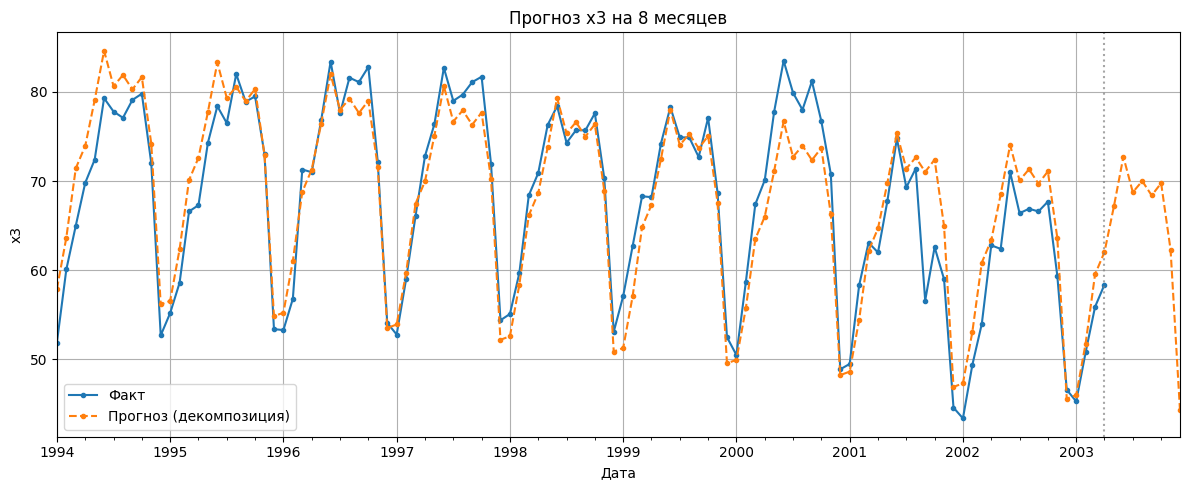

In [9]:
# визуализация прогноза
fig, ax = plt.subplots(figsize = (12, 5))

y.plot(ax = ax, label = 'Факт', grid = True, linewidth = 1.5, marker = 'o', markersize = 3)
forecast_dec['x3'].plot(
    ax = ax,
    label = 'Прогноз (декомпозиция)',
    linewidth = 1.5,
    linestyle = '--',
    marker = 'o',
    markersize = 3,
    grid = True,
)

ax.axvline(y.index.max(), color='gray', linestyle=':', alpha=0.7)
ax.set_title('Прогноз x3 на 8 месяцев')
ax.set_xlabel('Дата')
ax.set_ylabel('x3')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
actual = y
predicted = y_past

# метрики
mae_decomp = mean_absolute_error(actual, predicted)
mape_decomp = mean_absolute_percentage_error(actual, predicted)
r2_decomp = r2_score(actual, predicted)

print(f"MAE: {mae_decomp:.4f}")
print(f"MAPE: {mape_decomp:.2%}")
print(f"R2: {r2_decomp:.4f}")

MAE: 2.8911
MAPE: 4.41%
R2: 0.8804


# Лабортаорная работа №4

Спрогнозировать x3 на 8 месяцев методом экспоненционального сглаживания.

In [11]:
fit1 = ExponentialSmoothing(
    y, 
    seasonal_periods = 12,
    trend = 'additive', 
    seasonal='additive', 
    damped_trend = True).fit()

forecast_exp = fit1.predict(0, 119)
forecast_exp

1994-01-01    52.337911
1994-02-01    58.389221
1994-03-01    66.765039
1994-04-01    68.800135
1994-05-01    74.484099
                ...    
2003-08-01    67.515102
2003-09-01    66.017276
2003-10-01    67.498913
2003-11-01    60.004298
2003-12-01    42.666622
Freq: MS, Length: 120, dtype: float64

In [12]:
fit1.params

{'smoothing_level': 0.5310282961999183,
 'smoothing_trend': 0.0,
 'smoothing_seasonal': 0.0,
 'damping_trend': 0.9110953056105567,
 'initial_level': 68.52893606929219,
 'initial_trend': 0.2618007213005794,
 'initial_seasons': array([-16.42955067, -10.3630173 ,  -3.09366963,  -0.30168379,
          4.68696565,  10.48314056,   6.78149281,   8.15964138,
          6.66181111,   8.1434435 ,   0.64882444, -16.6888551 ]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

- **smoothing_level (α = 0.528)** — скорость обновления уровня
- **smoothing_trend (β = 0.0)** — скорость обновления тренда (постоянный тренд)
- **smoothing_seasonal (γ = 0.0)** — скорость обновления сезонности (фиксированная сезонность)
- **damping_trend (φ = 0.995)** — затухание тренда (почти линейный)
- **initial_level (69.09)** — начальный уровень
- **initial_trend (-0.087)** — начальный тренд (слабое падение)
- **initial_seasons** — сезонные коэффициенты по месяцам

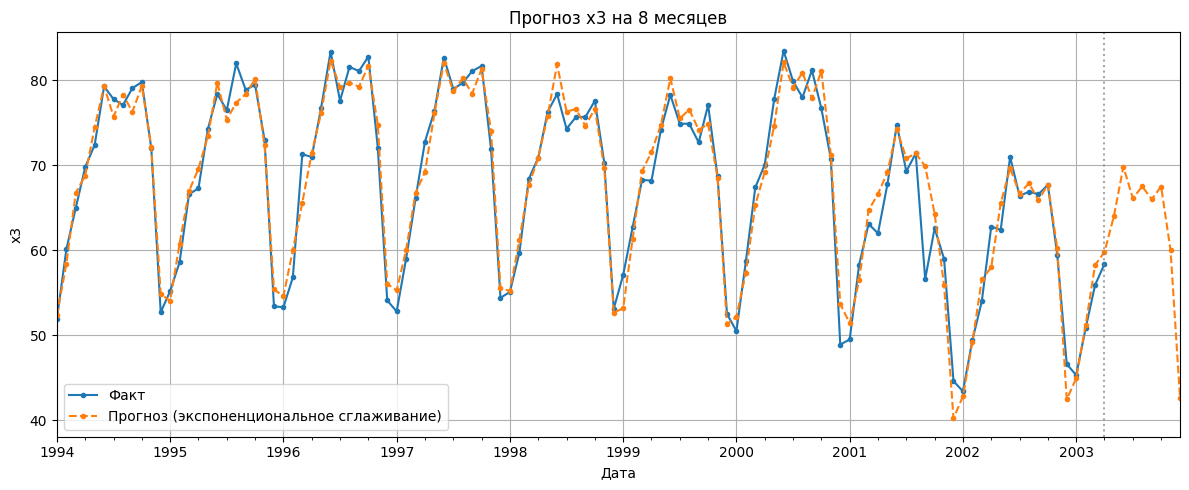

In [13]:
# визуализация прогноза
fig, ax = plt.subplots(figsize = (12, 5))

y.plot(ax = ax, label = 'Факт', grid = True, linewidth = 1.5, marker = 'o', markersize = 3)
forecast_exp.plot(
    ax = ax,
    label = 'Прогноз (экспоненциональное сглаживание)',
    linewidth = 1.5,
    linestyle = '--',
    marker = 'o',
    markersize = 3,
    grid = True,
)

ax.axvline(y.index.max(), color='gray', linestyle=':', alpha=0.7)
ax.set_title('Прогноз x3 на 8 месяцев')
ax.set_xlabel('Дата')
ax.set_ylabel('x3')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
actual = y
predicted = forecast_exp[:112]

# метрики
mae_exp = mean_absolute_error(actual, predicted)
mape_exp = mean_absolute_percentage_error(actual, predicted)
r2_exp = r2_score(actual, predicted)

print(f"MAE: {mae_exp:.4f}")
print(f"MAPE: {mape_exp:.2%}")
print(f"R2: {r2_exp:.4f}")

MAE: 1.7151
MAPE: 2.68%
R2: 0.9495


<!-- TODO -->

# Лабораторная работа №5

Спрогнозировать x3 на 8 месяцев методом ARIMA.

In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima

In [16]:
# проверка стационарности ряда с помощью теста Дикея-Фуллера
result_adf = adfuller(y)

print(f"p-value: {result_adf[1]:.6f}")

if result_adf[1] <= 0.05:
    print("ряд стационарен (отвергаем H0 при alpha = 0.05)")
else:
    print("ряд нестационарен (не отвергаем H0)")
    print("требуется дифференцирование (d >= 1)")

p-value: 0.887417
ряд нестационарен (не отвергаем H0)
требуется дифференцирование (d >= 1)


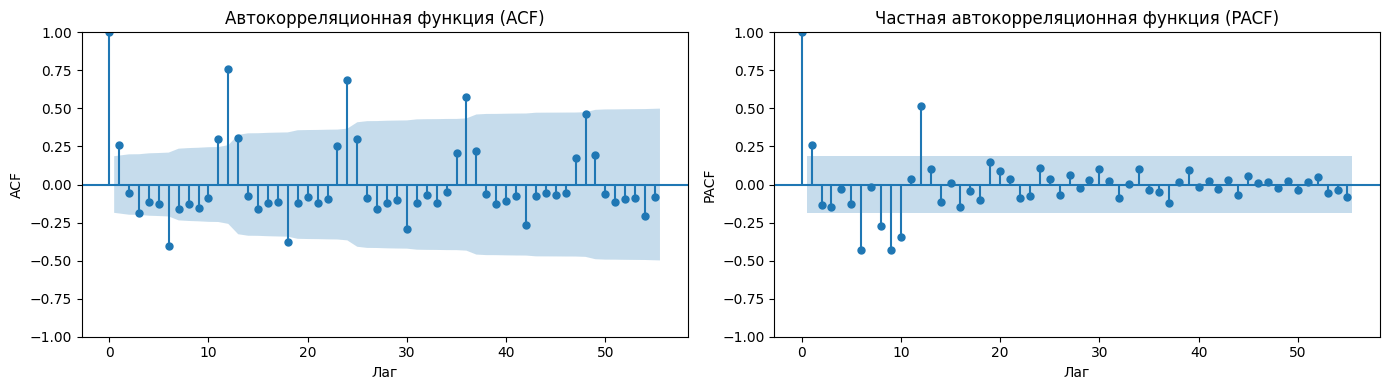

In [17]:
y_diff = y.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(y_diff, lags=len(y) // 2 - 1, ax=axes[0])
axes[0].set_title('Автокорреляционная функция (ACF)')
axes[0].set_xlabel('Лаг')
axes[0].set_ylabel('ACF')

plot_pacf(y_diff, lags=len(y) // 2 - 1, ax=axes[1], method='ywmle')
axes[1].set_title('Частная автокорреляционная функция (PACF)')
axes[1].set_xlabel('Лаг')
axes[1].set_ylabel('PACF')

plt.tight_layout()
plt.show()

- есть **ярко выраженная сезонность с периодом 12** (ACF(12)=0.759, PACF(12)=0.513)
- нужна **SARIMA**, а не простая ARIMA
- сезонная разность `D`: скорее всего нужна `D=1` (ACF(12) очень высокий)
- параметры `p` и `q`: по графикам не определяются однозначно - используйте `auto_arima`

In [18]:
auto_model = auto_arima(
    y,
    start_p=0, max_p=5,
    start_d=0, max_d=2,
    start_q=0, max_q=5,
    seasonal=True,
    m=12,
    max_P=2, 
    max_D=1,
    max_Q=2,
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

print(f"Порядок ARIMA (p, d, q): {auto_model.order}")
print(f"Сезонный порядок (P, D, Q, m): {auto_model.seasonal_order}")
print(f"\nAIC: {auto_model.aic():.2f}")
print(f"BIC: {auto_model.bic():.2f}")

p, d, q = auto_model.order
P, D, Q, m = auto_model.seasonal_order

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=1.05 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=755.537, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=629.359, Time=0.27 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=703.656, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=753.544, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=749.560, Time=0.06 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=inf, Time=0.51 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=587.750, Time=1.64 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=703.706, Time=0.29 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=588.568, Time=1.11 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=588.534, Time=1.24 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=inf, Time=1.55 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=590.713, Time=2.23 sec
 ARIMA(2,1,0)(1,0,1)[12] intercept   : AIC=589.642, Time=1.18 sec
 ARIMA(1,1,1)(1,0,1)[12] intercept   : AIC=58

### Несезонная часть (0,1,1)

| Параметр | Значение | За что отвечает |
|:---:|:---:|:---|
| **p=0** | AR = 0 | Прошлые значения ряда **не важны**. Модель не смотрит на то, что было в прошлом месяце. |
| **d=1** | Разность = 1 | Модель смотрит на **изменение** (разницу между соседними значениями), а не на абсолютные цифры. Убирает тренд. |
| **q=1** | MA = 1 | **Ошибка прошлого прогноза** влияет на текущий. Если в прошлый раз ошибся — поправит. |

### Сезонная часть (1,0,1)[12]

| Параметр | Значение | За что отвечает |
|:---:|:---:|:---|
| **P=1** | Сезонная AR = 1 | **Значение годичной давности** (ровно 12 месяцев назад) влияет на текущий прогноз. |
| **D=0** | Сезонная разность = 0 | Сезонный паттерн **стабильный**. Не нужно вычитать прошлогодний уровень — рисунок "зима-лето" не меняется со временем. |
| **Q=1** | Сезонная MA = 1 | **Ошибка годичной давности** влияет на текущий прогноз. Если прошлым декабрём ошибся — скорректирует этот декабрь. |
| **[12]** | Период = 12 | Данные **месячные**. Сезонный цикл — 12 месяцев. |

In [19]:
model_sarimax = SARIMAX(
    y,
    order=(p, d, q),
    seasonal_order=(P, D, Q, m),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_sarimax = model_sarimax.fit(disp=False, maxiter=200)

h = 8

forecast_in_sample = results_sarimax.get_prediction(start=0, end=len(y) - 1).predicted_mean
forecast_future = results_sarimax.get_forecast(steps=h).predicted_mean

# Склеиваем историю и будущий прогноз
forecast_sarimax = pd.concat([forecast_in_sample, forecast_future])
forecast_sarimax.iloc[0] = y.iloc[0]
forecast_future

2003-05-01    62.872080
2003-06-01    67.876448
2003-07-01    64.575127
2003-08-01    65.702139
2003-09-01    64.311803
2003-10-01    65.523179
2003-11-01    58.899604
2003-12-01    43.679514
Freq: MS, Name: predicted_mean, dtype: float64

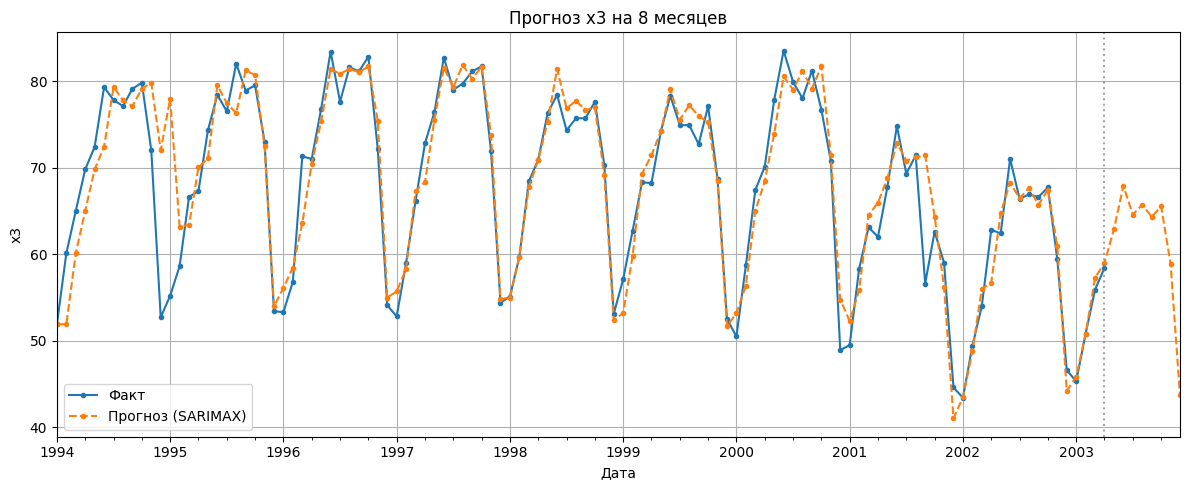

In [20]:
# визуализация прогноза
fig, ax = plt.subplots(figsize = (12, 5))

y.plot(ax = ax, label = 'Факт', grid = True, linewidth = 1.5, marker = 'o', markersize = 3)
forecast_sarimax.plot(
    ax = ax,
    label = 'Прогноз (SARIMAX)',
    linewidth = 1.5,
    linestyle = '--',
    marker = 'o',
    markersize = 3,
    grid = True,
)

ax.axvline(y.index.max(), color='gray', linestyle=':', alpha=0.7)
ax.set_title('Прогноз x3 на 8 месяцев')
ax.set_xlabel('Дата')
ax.set_ylabel('x3')
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
actual = y
predicted = results_sarimax.fittedvalues
predicted.iloc[0] = y.iloc[0]

# метрики
mae_arima = mean_absolute_error(actual, predicted)
mape_arima = mean_absolute_percentage_error(actual, predicted)
r2_arima = r2_score(actual, predicted)

print(f"MAE: {mae_arima:.4f}")
print(f"MAPE: {mape_arima:.2%}")
print(f"R2: {r2_arima:.4f}")

MAE: 2.4802
MAPE: 3.90%
R2: 0.8496


## Вывод

In [22]:
comparison_table = pd.DataFrame({
    'Метод': ['Декомпозиция', 'Экспоненциальное сглаживание', 'SARIMAX'],
    'MAE': [mae_decomp, mae_exp, mae_arima],
    'MAPE': [mape_decomp, mape_exp, mape_arima],
    'R²': [r2_decomp, r2_exp, r2_arima]
})

comparison_table['MAE'] = comparison_table['MAE'].apply(lambda x: f'{x:.4f}')
comparison_table['MAPE'] = comparison_table['MAPE'].apply(lambda x: f'{x:.2%}')
comparison_table['R²'] = comparison_table['R²'].apply(lambda x: f'{x:.2%}')
comparison_table

,Метод,MAE,MAPE,R²
0,Декомпозиция,2.8911,4.41%,88.04%
1,Экспоненциальное сглаживание,1.7151,2.68%,94.95%
2,SARIMAX,2.4802,3.90%,84.96%


- лучшая модель - экспоненциальное сглаживание;
- SARIMAX показала средний результат;
- декомпозиция оказалась самой слабой.

# Лабораторная работа №7

Спрогнозировать x3 на 8 месяцев методами сезонной индикации и авторегресии.

### Метод сезонной индикации

$$y_t = \beta_0 + \beta_1 \cdot t + \sum_{j=2}^{m} \gamma_j \cdot D_{j,t} + \varepsilon_t$$

*   $y_t$ — значение временного ряда в момент времени $t$.
*   $t$ — временной тренд ($1, 2, 3, \dots, n$).
*   $D_{j,t}$ — фиктивная (индикаторная) переменная для сезона $j$:
    $$D_{j,t} = \begin{cases} 1, & \text{если момент } t \text{ принадлежит сезону } j \\ 0, & \text{иначе} \end{cases}$$
*   $m$ — количество сезонов в году (например, 12 для месяцев).
*   $\beta_1$ — коэффициент тренда (на сколько меняется ряд за единицу времени).
*   $\gamma_j$ — сезонный коэффициент (на сколько значение в сезоне $j$ отличается от базового).
*   $\beta_0$ — базовый уровень (константа, включающая в себя влияние исключенного сезона).
*   $\varepsilon_t$ — случайная ошибка.

In [ ]:
import statsmodels.api as sm
# сбрасываем индексы
y_clean = y.reset_index(drop=True)
n = len(y_clean)

# Сохраняем месяцы из оригинальных дат
original_months = y.index.month.values

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,
        6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,
       11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,
        4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,
        9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,
        2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,
        7,  8,  9, 10, 11, 12,  1,  2,  3,  4])

In [73]:
# Создаем дамми-переменные для месяцев
month_dummies = pd.get_dummies(original_months, prefix='M', drop_first=True, dtype=float)
month_dummies = month_dummies.reset_index(drop=True)  # сбрасываем индекс

# Создаем тренд
t = np.arange(n)

# Объединяем
X = pd.DataFrame({'trend': t})
X = pd.concat([X, month_dummies], axis=1)
X = sm.add_constant(X)
X

,const,trend,M_2,M_3,M_4,M_5,M_6,M_7,M_8,M_9,M_10,M_11,M_12
0,1.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,1.0,107,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
108,1.0,108,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
109,1.0,109,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
110,1.0,110,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Обучаем модель
model_seasonal = sm.OLS(y_clean, X).fit()

# Определяем последний месяц в данных
last_month = original_months[-1]
last_year = y.index[-1].year

# Создаем будущие месяцы (продолжаем цикл)
future_months_list = []
current_month = last_month
current_year = last_year

for i in range(8):
    current_month += 1
    if current_month > 12:
        current_month = 1
        current_year += 1
    future_months_list.append(current_month)

future_months = np.array(future_months_list)

In [139]:
# Создаем дамми для будущих месяцев
future_dummies = pd.get_dummies(future_months, prefix='M', drop_first=False, dtype=float)

# Добавляем недостающие колонки
for col in month_dummies.columns:
    if col not in future_dummies.columns:
        future_dummies[col] = 0

# Приводим к правильному порядку
future_dummies = future_dummies[month_dummies.columns]

# Создаем тренд для прогноза
t_forecast = np.arange(n, n + 8)

# Объединяем
X_future = pd.DataFrame({'trend': t_forecast})
X_future = pd.concat([X_future, future_dummies], axis=1)
X_future = sm.add_constant(X_future)

# Убеждаемся, что колонки совпадают с обученной моделью
X_future = X_future[X.columns]
X_future

,const,trend,M_2,M_3,M_4,M_5,M_6,M_7,M_8,M_9,M_10,M_11,M_12
0,1.0,112,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,113,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,114,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,1.0,115,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.0,116,0,0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5,1.0,117,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6,1.0,118,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,1.0,119,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [140]:
# Прогноз
forecast_seasonal = model_seasonal.predict(X_future)

# Создаем даты для прогноза
last_date = y.index[-1]
future_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=8, freq='MS')
forecast_seasonal

0    66.906790
1    72.617901
2    68.829012
3    70.117901
4    68.529012
5    69.917901
6    62.329012
7    44.895679
dtype: float64

In [156]:
fitted_values = model_seasonal.predict(X)

fitted_series = pd.Series(fitted_values.values, index=y.index, name='x3_fitted')
forecast_series = pd.Series(forecast_seasonal.values, index=future_dates, name='x3_forecast')

forecast_seasonal_ind = pd.concat([fitted_series, forecast_series])
forecast_seasonal_ind

1994-01-01    57.033889
1994-02-01    63.033889
1994-03-01    70.233889
1994-04-01    72.953889
1994-05-01    78.154568
                ...    
2003-08-01    70.117901
2003-09-01    68.529012
2003-10-01    69.917901
2003-11-01    62.329012
2003-12-01    44.895679
Freq: MS, Length: 120, dtype: float64

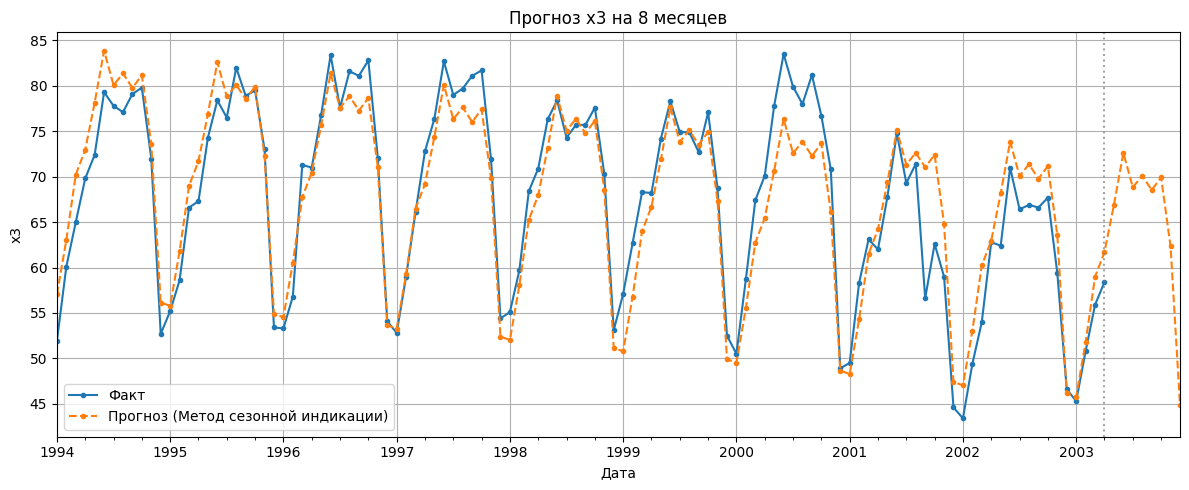

In [142]:
# визуализация прогноза
fig, ax = plt.subplots(figsize = (12, 5))

y.plot(ax = ax, label = 'Факт', grid = True, linewidth = 1.5, marker = 'o', markersize = 3)
forecast_seasonal_ind.plot(
    ax = ax,
    label = 'Прогноз (Метод сезонной индикации)',
    linewidth = 1.5,
    linestyle = '--',
    marker = 'o',
    markersize = 3,
    grid = True,
)

ax.axvline(y.index.max(), color='gray', linestyle=':', alpha=0.7)
ax.set_title('Прогноз x3 на 8 месяцев')
ax.set_xlabel('Дата')
ax.set_ylabel('x3')
ax.legend()
plt.tight_layout()
plt.show()

In [143]:
actual = y
predicted = fitted_values.values

# метрики
mae_seasonal_ind = mean_absolute_error(actual, predicted)
mape_seasonal_ind = mean_absolute_percentage_error(actual, predicted)
r2_seasonal_ind = r2_score(actual, predicted)

print(f"MAE: {mae_seasonal_ind:.4f}")
print(f"MAPE: {mape_seasonal_ind:.2%}")
print(f"R2: {r2_seasonal_ind:.4f}")

MAE: 2.8650
MAPE: 4.34%
R2: 0.8827


In [144]:
# Коэффициенты модели
coef_df = pd.DataFrame({
    'Признак': model_seasonal.params.index,
    'Коэффициент': model_seasonal.params.values.round(4),
    'P-value': model_seasonal.pvalues.values.round(4)
})
coef_df

,Признак,Коэффициент,P-value
0,const,57.0339,0.0000
1,trend,-0.1041,0.0000
2,M_2,6.1041,0.0007
3,M_3,13.4083,0.0000
4,M_4,16.2324,0.0000
5,M_5,21.5373,0.0000
6,M_6,27.3525,0.0000
7,M_7,23.6678,0.0000
8,M_8,25.0608,0.0000
9,M_9,23.5761,0.0000


In [145]:
# Отдельно выведем сезонные эффекты
print(f"Константа (базовый уровень для месяца 12): {model_seasonal.params['const']:.2f}")
print(f"Тренд (изменение за период): {model_seasonal.params['trend']:.4f}")
print("\nСезонные отклонения от базового месяца (12):")
for col in month_dummies.columns:
    month_num = int(col.split('_')[1])
    effect = model_seasonal.params[col]
    print(f"  Месяц {month_num}: {effect:+.2f}")

Константа (базовый уровень для месяца 12): 57.03
Тренд (изменение за период): -0.1041

Сезонные отклонения от базового месяца (12):
  Месяц 2: +6.10
  Месяц 3: +13.41
  Месяц 4: +16.23
  Месяц 5: +21.54
  Месяц 6: +27.35
  Месяц 7: +23.67
  Месяц 8: +25.06
  Месяц 9: +23.58
  Месяц 10: +25.07
  Месяц 11: +17.58
  Месяц 12: +0.26


### Авторегрессия

$$y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \dots + \phi_p y_{t-p} + \varepsilon_t$$


*   $y_t$ — значение временного ряда в текущий момент времени $t$.
*   $y_{t-i}$ — значение ряда в прошлые моменты времени (лаги).
*   $\phi_i$ — коэффициенты авторегрессии (веса влияния прошлых значений).
*   $p$ — порядок модели (количество предыдущих значений, влияющих на текущее).
*   $c$ — константа (свободный член).
*   $\varepsilon_t$ — случайная ошибка (белый шум).

In [157]:
from statsmodels.tsa.ar_model import AutoReg

# выбираем лаг равный 12 (годовая сезонность)
lag = 12
model_ar = AutoReg(y, lags=lag, old_names=False, seasonal=True, period=12)
res_ar = model_ar.fit()

In [147]:
# прогноз на 8 шагов вперед
start = len(y)
end = len(y) + 7
pred_ar = res_ar.predict(start=start, end=end)

In [ ]:
# создаем индекс будущих дат
last_date = y.index[-1]
future_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=8, freq='MS')

pred_ar = pd.Series(pred_ar.values, index=future_index, name='x3')
y_fitted = res_ar.fittedvalues
forecast_ar = pd.concat([y[:lag], y_fitted, pred_ar])
forecast_ar

1994-01-01    51.900000
1994-02-01    60.100000
1994-03-01    65.000000
1994-04-01    69.800000
1994-05-01    72.400000
                ...    
2003-08-01    68.065765
2003-09-01    66.120921
2003-10-01    68.380602
2003-11-01    61.508238
2003-12-01    43.503139
Freq: MS, Length: 120, dtype: float64

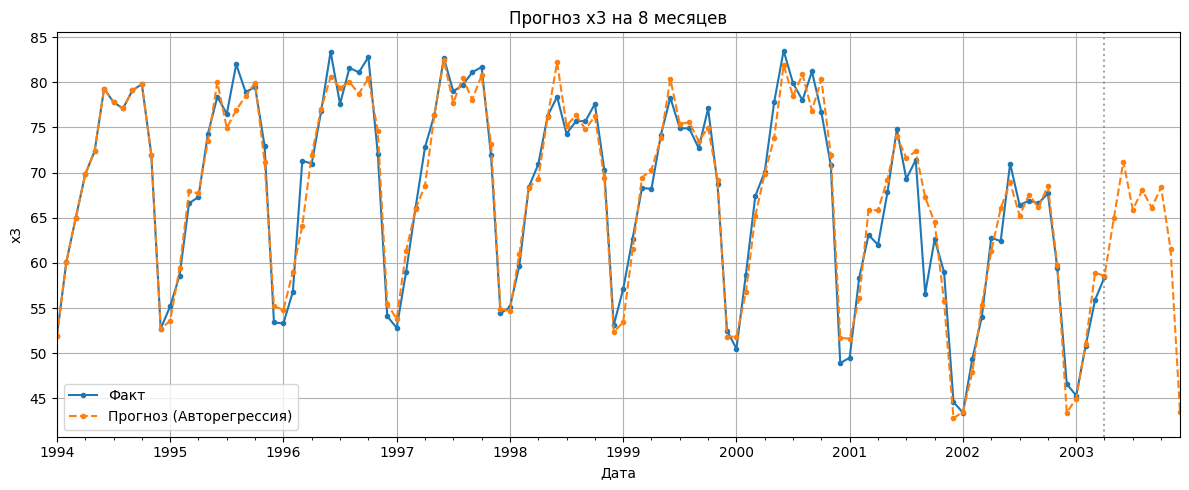

In [149]:
# визуализация прогноза
fig, ax = plt.subplots(figsize = (12, 5))

y.plot(ax = ax, label = 'Факт', grid = True, linewidth = 1.5, marker = 'o', markersize = 3)
forecast_ar.plot(
    ax = ax,
    label = 'Прогноз (Авторегрессия)',
    linewidth = 1.5,
    linestyle = '--',
    marker = 'o',
    markersize = 3,
    grid = True,
)

ax.axvline(y.index.max(), color='gray', linestyle=':', alpha=0.7)
ax.set_title('Прогноз x3 на 8 месяцев')
ax.set_xlabel('Дата')
ax.set_ylabel('x3')
ax.legend()
plt.tight_layout()
plt.show()

In [150]:
actual = y
predicted = pd.concat([y[:lag], y_fitted])

# метрики
mae_ar = mean_absolute_error(actual, predicted)
mape_ar = mean_absolute_percentage_error(actual, predicted)
r2_ar = r2_score(actual, predicted)

print(f"MAE: {mae_ar:.4f}")
print(f"MAPE: {mape_ar:.2%}")
print(f"R2: {r2_ar:.4f}")

MAE: 1.5289
MAPE: 2.33%
R2: 0.9583


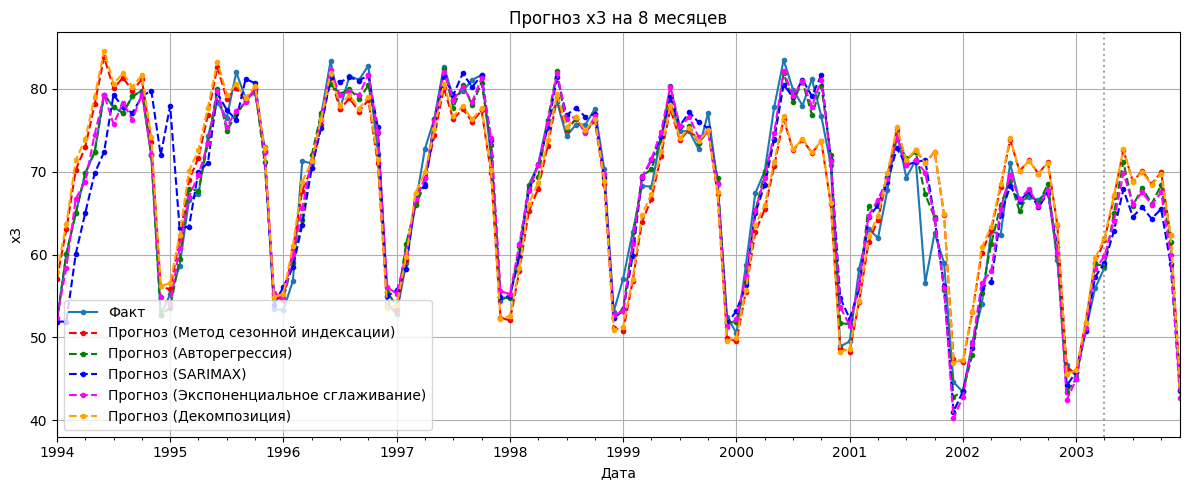

In [151]:
# визуализация прогноза
fig, ax = plt.subplots(figsize = (12, 5))

y.plot(ax = ax, label = 'Факт', grid = True, linewidth = 1.5, marker = 'o', markersize = 3)

forecasts = {
    'Метод сезонной индексации': [forecast_seasonal_ind, 'r'],
    'Авторегрессия': [forecast_ar, 'g'],
	'SARIMAX': [forecast_sarimax, 'b'],
	'Экспоненциальное сглаживание': [forecast_exp,  'magenta'],
	'Декомпозиция': [forecast_dec['x3'], 'orange']
}

import random
for key, forecast in forecasts.items():
    forecast[0].plot(
        ax = ax,
		label = f'Прогноз ({key})',
		linewidth = 1.5,
		linestyle = '--',
		marker = 'o',
		markersize = 3,
		grid = True, 
  		c = forecast[1] 
	)

ax.axvline(y.index.max(), color='gray', linestyle=':', alpha=0.7)
ax.set_title('Прогноз x3 на 8 месяцев')
ax.set_xlabel('Дата')
ax.set_ylabel('x3')
ax.legend()
plt.tight_layout()
plt.show()

In [152]:
comparison_table = pd.DataFrame({
    'Метод': ['Декомпозиция', 'Экспоненциальное сглаживание', 'SARIMAX', 'Сезонная индексация', 'Авторегрессия'],
    'MAE': [mae_decomp, mae_exp, mae_arima, mae_seasonal_ind, mae_ar],
    'MAPE': [mape_decomp, mape_exp, mape_arima, mape_seasonal_ind, mape_ar],
    'R²': [r2_decomp, r2_exp, r2_arima, r2_seasonal_ind, r2_ar]
})

comparison_table['MAE'] = comparison_table['MAE'].apply(lambda x: f'{x:.4f}')
comparison_table['MAPE'] = comparison_table['MAPE'].apply(lambda x: f'{x:.2%}')
comparison_table['R²'] = comparison_table['R²'].apply(lambda x: f'{x:.2%}')
comparison_table.sort_values(by = ['MAE', 'MAPE'])

,Метод,MAE,MAPE,R²
4,Авторегрессия,1.5289,2.33%,95.83%
1,Экспоненциальное сглаживание,1.7151,2.68%,94.95%
2,SARIMAX,2.4802,3.90%,84.96%
3,Сезонная индексация,2.8650,4.34%,88.27%
0,Декомпозиция,2.8911,4.41%,88.04%
